In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Summary_of_Results_3_18_2026.csv')

# Phase 1: Basic Data Cleaning

In [3]:
# How many missing COST before cleaning?
print(df['COST'].isna().sum())

# Drop rows with missing COST
df = df.dropna(subset=['COST'])



116


In [4]:
# Convert FAILDATE to datetime
df['FAILDATE'] = pd.to_datetime(df['FAILDATE'], errors='coerce')


In [5]:
#Check if there are rows with non-positive Assets
(df['QBFASSET'] <= 0).sum()

np.int64(0)

In [6]:
# Drop rows with missing values
df = df.dropna()


# Phase 2: Target & Feature Engineering

In [7]:
# Create the Target Veriable LGD = COST/ QBFASSET
df['LGD'] = df['COST'] / df['QBFASSET']
df['LGD'].describe()


count    3476.000000
mean        0.257273
std         0.324592
min        -0.200323
25%         0.094596
50%         0.198140
75%         0.318789
max        10.871010
Name: LGD, dtype: float64

In [8]:
#Create Financial Ratio Features
df['Deposit_to_Asset_Ratio'] = df['QBFDEP'] / df['QBFASSET']
df['Deposit_to_Asset_Ratio'].describe()


count    3476.000000
mean        0.958182
std         0.213777
min         0.000000
25%         0.893224
50%         0.955236
75%         1.000745
max         8.897978
Name: Deposit_to_Asset_Ratio, dtype: float64

In [9]:
#Create the Spatial/Temporal Feature -
#How many banks in the same state failed in the 365 days before this bank’s failure.
df = df.sort_values('FAILDATE')

df['STATE'] = df['CITYST'].str[-2:]

df['State_Failures_Last_12M'] = 0

for i in range(len(df)):
    current_state = df.iloc[i]['STATE']
    current_date = df.iloc[i]['FAILDATE']
    window_start = current_date - pd.Timedelta(days=365)
    
    count = df[
        (df['STATE'] == current_state) &
        (df['FAILDATE'] < current_date) &
        (df['FAILDATE'] >= window_start)
    ].shape[0]
    
    df.at[df.index[i], 'State_Failures_Last_12M'] = count


# New features: 
US Unemployment Rate : https://fred.stlouisfed.org/series/UNRATE

FED rate: https://fred.stlouisfed.org/data/FEDFUNDS





In [10]:
unemp = pd.read_csv('US_unemployment_rate.csv')
fed_rate = pd.read_csv('avg Federal Funds Effective Rate.csv')

In [11]:
unemp.head()

,observation_date,UNRATE
0,1/01/1976,7.7
1,1/01/1977,7.1
2,1/01/1978,6.1
3,1/01/1979,5.9
4,1/01/1980,7.2


In [12]:
unemp['observation_date'] = pd.to_datetime(unemp['observation_date'])
unemp['YEAR'] = unemp['observation_date'].dt.year

annual_unemp = unemp.groupby('YEAR')['UNRATE'].mean().reset_index()
annual_unemp = annual_unemp.dropna()
print(annual_unemp)

    YEAR  UNRATE
0   1976    7.70
1   1977    7.10
2   1978    6.10
3   1979    5.90
4   1980    7.20
5   1981    7.60
6   1982    9.70
7   1983    9.60
8   1984    7.50
9   1985    7.20
10  1986    7.00
11  1987    6.20
12  1988    5.50
13  1989    5.30
14  1990    5.60
15  1991    6.90
16  1992    7.50
17  1993    6.90
18  1994    6.10
19  1995    5.60
20  1996    5.40
21  1997    4.90
22  1998    4.50
23  1999    4.20
24  2000    4.00
25  2001    4.70
26  2002    5.80
27  2003    6.00
28  2004    5.50
29  2005    5.10
30  2006    4.60
31  2007    4.60
32  2008    5.80
33  2009    9.30
34  2010    9.60
35  2011    8.90
36  2012    8.10
37  2013    7.40
38  2014    6.20
39  2015    5.30
40  2016    4.90
41  2017    4.40
42  2018    3.90
43  2019    3.70
44  2020    8.10
45  2021    5.40
46  2022    3.70
47  2023    3.60
48  2024    4.00
49  2025    4.26
50  2026    4.35


In [13]:
fed_rate.head()

,DATE,VALUE
0,1/07/1954,0.80
1,1/08/1954,1.22
2,1/09/1954,1.07
3,1/10/1954,0.85
4,1/11/1954,0.83


In [14]:
fed_rate['DATE'] = pd.to_datetime(fed_rate['DATE'])
fed_rate['YEAR'] = fed_rate['DATE'].dt.year

annual_fed = fed_rate.groupby('YEAR')['VALUE'].mean().reset_index()
annual_fed.rename(columns={'VALUE': 'FEDFUNDS'}, inplace=True)
print(annual_fed.head())

   YEAR  FEDFUNDS
0  1954  1.008333
1  1955  1.785000
2  1956  2.728333
3  1957  3.105000
4  1958  1.572500


In [15]:
df['YEAR'] = df['FAILDATE'].dt.year
df = df.merge(annual_unemp, on='YEAR', how='left')
df = df.merge(annual_fed, on='YEAR', how='left')


### Phase 3: Prepare Data for ML models

### **Definitely drop:**
- **CERT** → ID number, no predictive meaning  
- **FIN** → internal FDIC ID, useless  
- **ID** → internal dataset ID  
- **NAME** → bank name (categorical noise, too many unique values)  
- **CITYST** → replaced by **STATE**  
- **RESTYPE** → always “FAILURE”, zero variance  
- **FAILDATE** → replaced by **YEAR**  

- **COST** → already converted to LGD  



In [16]:
cols_to_drop = [
    'CERT', 'FIN', 'ID', 'NAME', 'CITYST', 
    'RESTYPE', 'FAILDATE', 'COST'
]

df = df.drop(columns=cols_to_drop)


In [17]:
categorical_cols = ['CHCLASS1', 'RESTYPE1', 'SAVR', 'STATE']
numerical_cols = [
    'QBFASSET', 'QBFDEP', 'Deposit_to_Asset_Ratio',
    'State_Failures_Last_12M', 'YEAR', 'UNRATE', 'FEDFUNDS'
]
target = 'LGD'


In [18]:
# One-hot encode categorical variables
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


In [19]:
#Scale numerical features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])


In [20]:
#Final dataset ready for modeling
X = df_encoded.drop(columns=[target])
y = df_encoded[target]
print(X.shape, y.shape)

(3476, 78) (3476,)


In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
results = []

In [147]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
lr = LinearRegression()
lr.fit(X_train, y_train)
pred = lr.predict(X_test)

results.append({
    'Model': 'Linear Regression',
    'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
    'R2': r2_score(y_test, pred)
})

In [148]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100]}
ridge = GridSearchCV(Ridge(), ridge_params, cv=5)
ridge.fit(X_train, y_train)
pred = ridge.predict(X_test)

results.append({
    'Model': 'Ridge',
    'Best Params': ridge.best_params_,
    'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
    'R2': r2_score(y_test, pred)
})

In [149]:
from sklearn.linear_model import Lasso
lasso_params = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1]}
lasso = GridSearchCV(Lasso(max_iter=5000), lasso_params, cv=5)
lasso.fit(X_train, y_train)
pred = lasso.predict(X_test)

results.append({
    'Model': 'Lasso',
    'Best Params': lasso.best_params_,
    'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
    'R2': r2_score(y_test, pred)
})

In [150]:
from sklearn.ensemble import RandomForestRegressor
rf_params = {
    'n_estimators': [200, 400],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5]
}

rf = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=3)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)

results.append({
    'Model': 'Random Forest',
    'Best Params': rf.best_params_,
    'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
    'R2': r2_score(y_test, pred)
})

In [151]:
results_df = pd.DataFrame(results)
results_df

,Model,RMSE,R2,Best Params
0,Linear Regression,0.186763,0.543207,NaN
1,Ridge,0.185919,0.547326,{'alpha': 10}
2,Lasso,0.189582,0.529315,{'alpha': 0.001}
3,Random Forest,0.151391,0.699850,"{'max_depth': 20, 'min_samples_split': 5, 'n_e..."
4,Linear Regression,0.186763,0.543207,NaN
5,Ridge,0.185919,0.547326,{'alpha': 10}
6,Lasso,0.189582,0.529315,{'alpha': 0.001}
7,Random Forest,0.151391,0.699850,"{'max_depth': 20, 'min_samples_split': 5, 'n_e..."


Random Forest appears to be the best model overall. It has the lowest RMSE (0.151391) and highest R² (0.699850), indicating better predictive accuracy and fit compared to the others. The residual plot for Random Forest likely shows more random scatter around zero with fewer obvious patterns, suggesting a stronger model fit.

In [145]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_residuals(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred

    plt.figure(figsize=(6,6))
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Predicted")
    plt.ylabel("Residuals")
    plt.title(f"Residuals vs Predicted: {title}")
    plt.show()


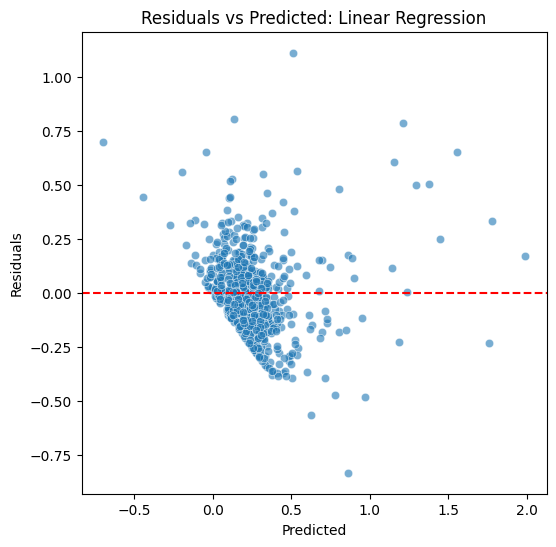

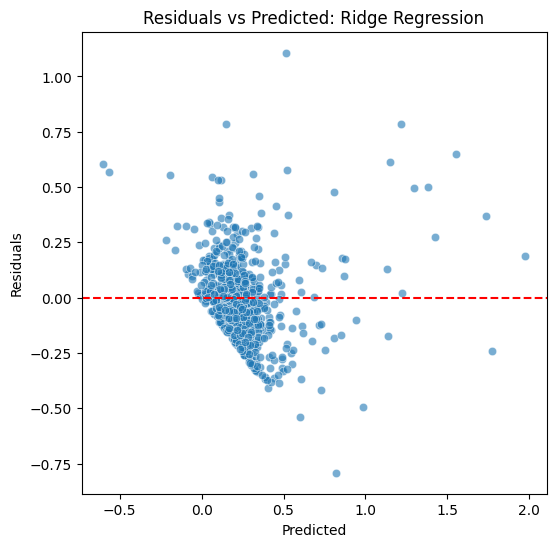

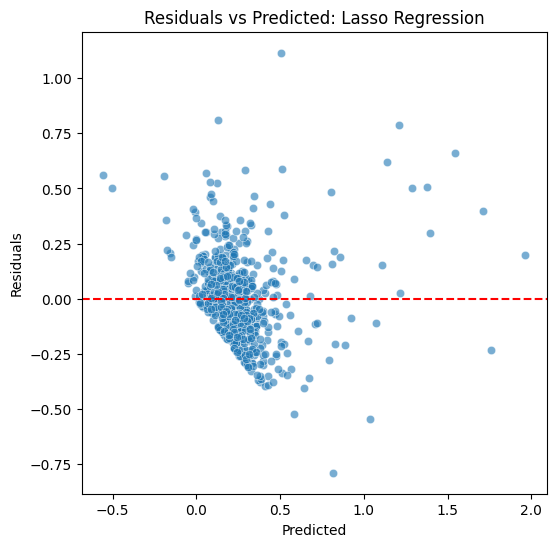

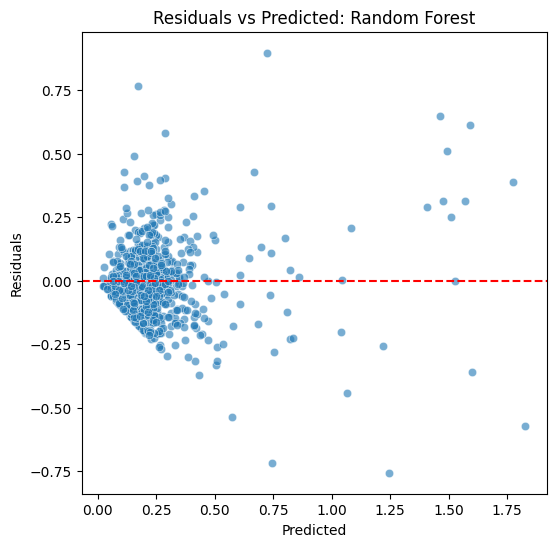

In [152]:
plot_residuals(lr, X_test, y_test, "Linear Regression")
plot_residuals(ridge.best_estimator_, X_test, y_test, "Ridge Regression")
plot_residuals(lasso.best_estimator_, X_test, y_test, "Lasso Regression")
plot_residuals(rf.best_estimator_, X_test, y_test, "Random Forest")


c:\Users\honga\ML_Project\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


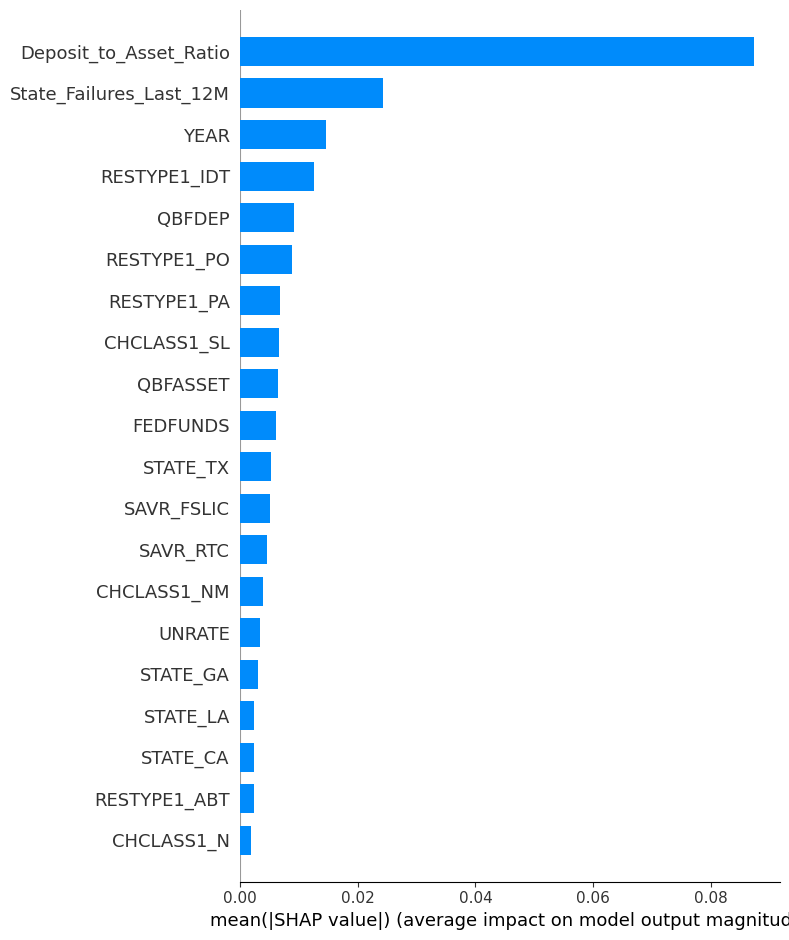

In [153]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(rf.best_estimator_)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test, plot_type="bar")


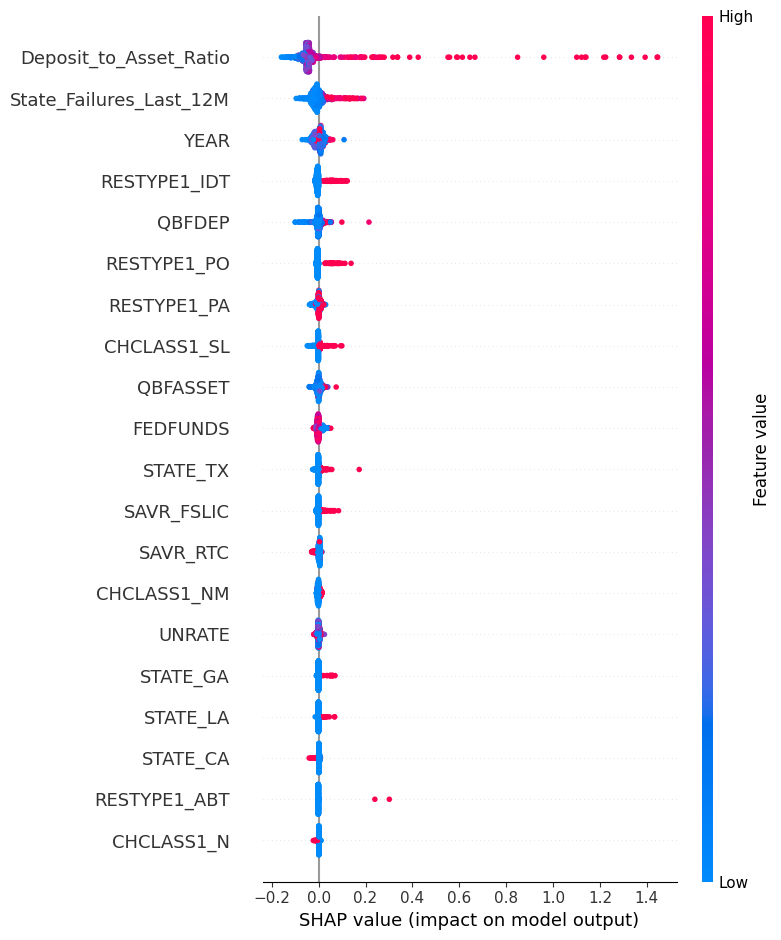

In [154]:
shap.summary_plot(shap_values, X_test)


###  **Deposit_to_Asset_Ratio**  
- High ratios (red) → push LGD **up**  
- Low ratios (blue) → push LGD **down**  
This makes sense: banks with high deposit-to-asset ratios may be riskier.

###  **State_Failures_Last_12M**  
- High values → increase LGD  
This means systemic stress in a state affects individual bank losses.

###  **YEAR**  
- Later years may push LGD up or down depending on macro conditions.

###  **Macro variables (UNRATE, FEDFUNDS)**  
They appear lower in importance but still contribute.

###  **Categorical encodings (STATE_TX, RESTYPE1_PO, etc.)**  
These matter, but less than your engineered features.


# Phase 4: Binary Classification Task - Predicting High Loss Banks

In [23]:
# Create binary classification target: 1 if LGD > 0.2, else 0
df_encoded_classification = df_encoded.copy()
df_encoded_classification['LGD_class'] = (df_encoded_classification['LGD'] > 0.2).astype(int)

print(f"Classification Target Distribution:\n{df_encoded_classification['LGD_class'].value_counts()}")
print(f"Percentage:\n{df_encoded_classification['LGD_class'].value_counts(normalize=True)}")

Classification Target Distribution:
LGD_class
0    1756
1    1720
Name: count, dtype: int64
Percentage:
LGD_class
0    0.505178
1    0.494822
Name: proportion, dtype: float64


In [24]:
# Prepare feature matrix and target for classification
X_class = df_encoded_classification.drop(columns=[target, 'LGD_class'])
y_class = df_encoded_classification['LGD_class']

# Split data for classification  
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

print(f"Classification Dataset Shapes: {X_train_class.shape}, {X_test_class.shape}")

Classification Dataset Shapes: (2780, 78), (696, 78)


In [25]:
# Initialize results for classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

classification_results = []

# Logistic Regression
lr_class = LogisticRegression(random_state=42, max_iter=1000)
lr_class.fit(X_train_class, y_train_class)
lr_pred = lr_class.predict(X_test_class)
lr_pred_proba = lr_class.predict_proba(X_test_class)[:, 1]

classification_results.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test_class, lr_pred),
    'Precision': precision_score(y_test_class, lr_pred),
    'Recall': recall_score(y_test_class, lr_pred),
    'F1': f1_score(y_test_class, lr_pred),
    'AUC': roc_auc_score(y_test_class, lr_pred_proba)
})

print("Logistic Regression trained")

Logistic Regression trained


In [27]:
from sklearn.model_selection import GridSearchCV

# Gradient Boosting Classifier
gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}
gb_class = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_params, cv=5)
gb_class.fit(X_train_class, y_train_class)
gb_pred = gb_class.predict(X_test_class)
gb_pred_proba = gb_class.best_estimator_.predict_proba(X_test_class)[:, 1]

classification_results.append({
    'Model': 'Gradient Boosting',
    'Best Params': gb_class.best_params_,
    'Accuracy': accuracy_score(y_test_class, gb_pred),
    'Precision': precision_score(y_test_class, gb_pred),
    'Recall': recall_score(y_test_class, gb_pred),
    'F1': f1_score(y_test_class, gb_pred),
    'AUC': roc_auc_score(y_test_class, gb_pred_proba)
})

print("Gradient Boosting trained")

Gradient Boosting trained


In [28]:
# Random Forest Classifier
rf_params = {
    'n_estimators': [200, 400],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5]
}
rf_class = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=3)
rf_class.fit(X_train_class, y_train_class)
rf_pred = rf_class.predict(X_test_class)
rf_pred_proba = rf_class.best_estimator_.predict_proba(X_test_class)[:, 1]

classification_results.append({
    'Model': 'Random Forest',
    'Best Params': rf_class.best_params_,
    'Accuracy': accuracy_score(y_test_class, rf_pred),
    'Precision': precision_score(y_test_class, rf_pred),
    'Recall': recall_score(y_test_class, rf_pred),
    'F1': f1_score(y_test_class, rf_pred),
    'AUC': roc_auc_score(y_test_class, rf_pred_proba)
})

print("Random Forest trained")

Random Forest trained


In [29]:
# Classification Results Comparison
classification_results_df = pd.DataFrame(classification_results)
classification_results_df

,Model,Accuracy,Precision,Recall,F1,AUC,Best Params
0,Logistic Regression,0.683908,0.687316,0.671470,0.679300,0.748388,NaN
1,Gradient Boosting,0.699713,0.699422,0.697406,0.698413,0.774312,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
2,Random Forest,0.722701,0.721264,0.723343,0.722302,0.798849,"{'max_depth': 20, 'min_samples_split': 5, 'n_e..."


In [30]:
# Confusion Matrices and Classification Reports
from sklearn.metrics import confusion_matrix, classification_report

def plot_classification_metrics(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    # Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Low Loss (≤0.2)', 'High Loss (>0.2)'],
                yticklabels=['Low Loss (≤0.2)', 'High Loss (>0.2)'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(f"Confusion Matrix: {title}")
    plt.tight_layout()
    plt.show()
    
    # Classification Report
    print(f"\n{'='*60}")
    print(f"{title} - Classification Report")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, 
                              target_names=['Low Loss (≤0.2)', 'High Loss (>0.2)']))

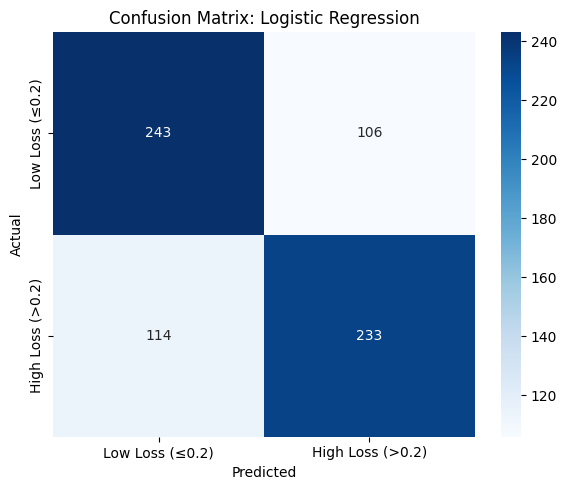


Logistic Regression - Classification Report
                  precision    recall  f1-score   support

 Low Loss (≤0.2)       0.68      0.70      0.69       349
High Loss (>0.2)       0.69      0.67      0.68       347

        accuracy                           0.68       696
       macro avg       0.68      0.68      0.68       696
    weighted avg       0.68      0.68      0.68       696



In [32]:
import seaborn as sns
# Plot Logistic Regression
plot_classification_metrics(lr_class, X_test_class, y_test_class, "Logistic Regression")

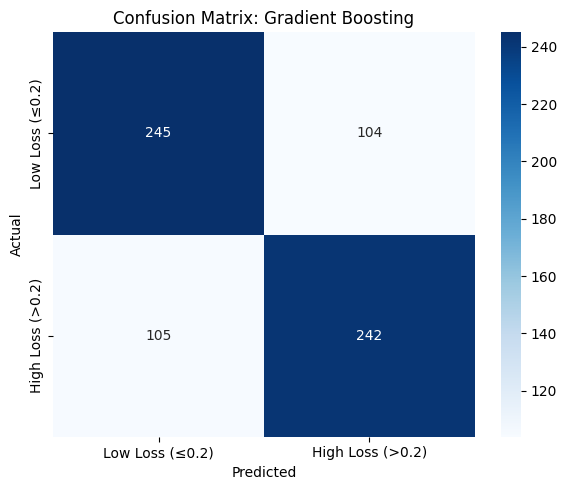


Gradient Boosting - Classification Report
                  precision    recall  f1-score   support

 Low Loss (≤0.2)       0.70      0.70      0.70       349
High Loss (>0.2)       0.70      0.70      0.70       347

        accuracy                           0.70       696
       macro avg       0.70      0.70      0.70       696
    weighted avg       0.70      0.70      0.70       696



In [33]:
# Plot Gradient Boosting
plot_classification_metrics(gb_class.best_estimator_, X_test_class, y_test_class, "Gradient Boosting")

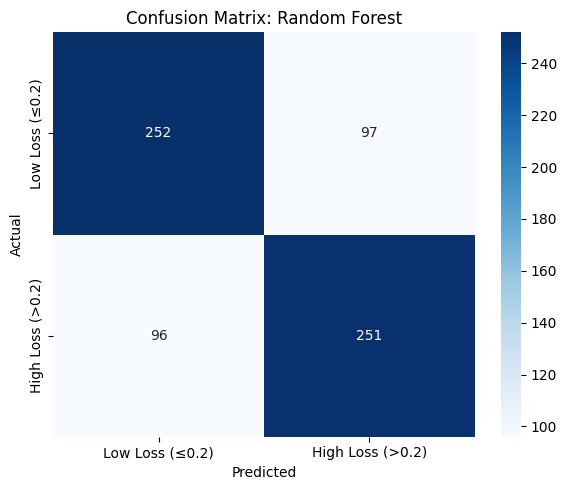


Random Forest - Classification Report
                  precision    recall  f1-score   support

 Low Loss (≤0.2)       0.72      0.72      0.72       349
High Loss (>0.2)       0.72      0.72      0.72       347

        accuracy                           0.72       696
       macro avg       0.72      0.72      0.72       696
    weighted avg       0.72      0.72      0.72       696



In [34]:
# Plot Random Forest
plot_classification_metrics(rf_class.best_estimator_, X_test_class, y_test_class, "Random Forest")

C:\Users\honga\AppData\Local\Temp\ipykernel_6732\2674151402.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_class, x='Importance', y='Feature', palette='viridis')


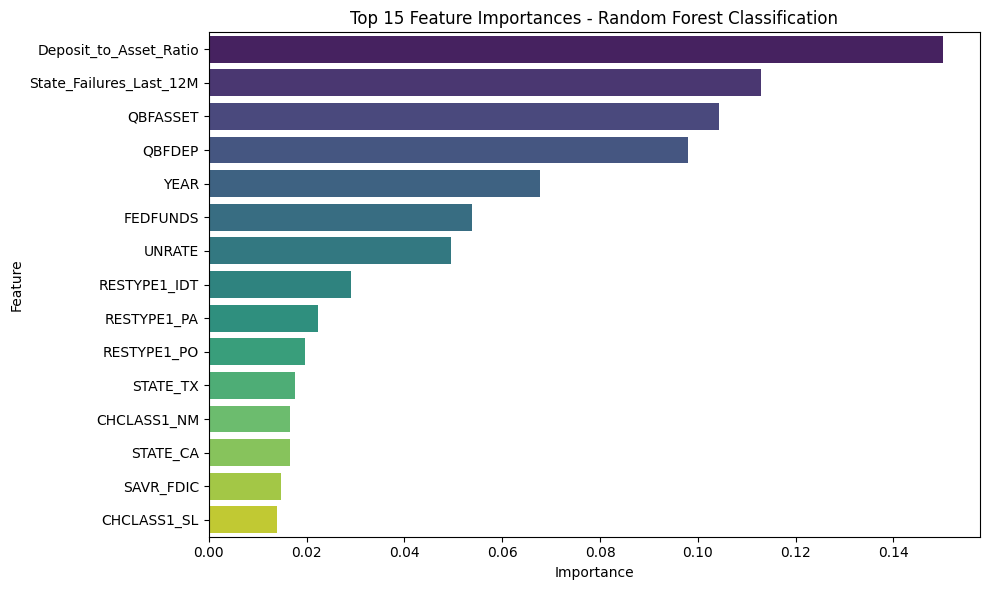

In [35]:
# Feature Importance for Random Forest Classification
feature_importance_class = pd.DataFrame({
    'Feature': X_class.columns,
    'Importance': rf_class.best_estimator_.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_class, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances - Random Forest Classification')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

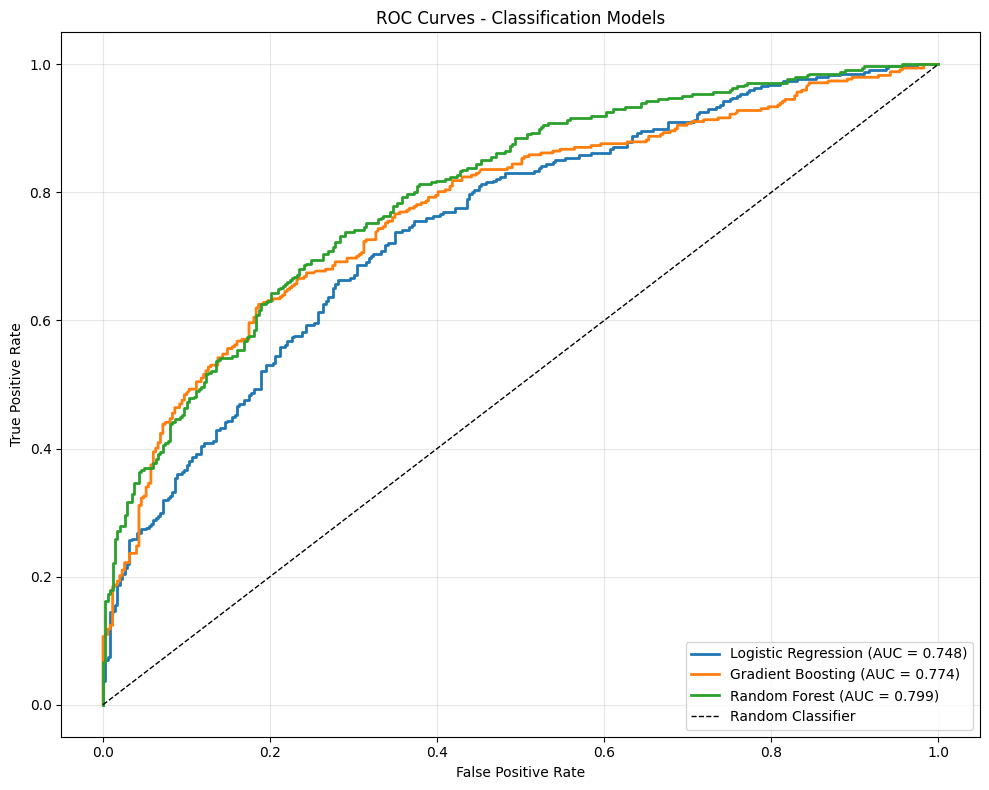

In [36]:
# ROC Curves Comparison
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test_class, lr_pred_proba)
roc_auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})', linewidth=2)

# Gradient Boosting ROC
fpr_gb, tpr_gb, _ = roc_curve(y_test_class, gb_pred_proba)
roc_auc_gb = auc(fpr_gb, tpr_gb)
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {roc_auc_gb:.3f})', linewidth=2)

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test_class, rf_pred_proba)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})', linewidth=2)

# Diagonal line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Classification Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Classification Task Summary

**Objective**: Predict whether a bank will have high loss (LGD > 0.2) or low loss (LGD ≤ 0.2)

**Class Distribution**:
- Low Loss (Class 0): Banks with LGD ≤ 0.2
- High Loss (Class 1): Banks with LGD > 0.2

**Models Evaluated**:
1. **Logistic Regression**: Simple baseline model
2. **Gradient Boosting**: Handles non-linear relationships with hyperparameter tuning
3. **Random Forest**: Ensemble method with best feature importance insights

**Key Metrics**:
- **Accuracy**: Overall correctness of predictions
- **Precision**: Of predicted high-loss banks, how many were actually high-loss
- **Recall**: Of actual high-loss banks, how many did the model identify  
- **F1 Score**: Balanced measure of precision and recall
- **AUC**: Ability to distinguish between classes (0.5 = random, 1.0 = perfect)

### Among all tested models, the Random Forest classifier achieved the highest performance across every evaluation metric, including Accuracy, Precision, Recall, F1, and AUC. With an AUC of 0.799, it demonstrates the strongest ability to distinguish between the two classes, making it the most reliable model for our binary classification task